In [1]:
!pip install scikit-learn pandas numpy joblib matplotlib

In [2]:
import re, random, numpy as np, pandas as pd
random.seed(42); np.random.seed(42)

spam = [
    "Gana dinero fácil en 24 horas, haz clic aquí",
    "Has sido seleccionado para un premio, comparte tus datos",
    "Tu cuenta será cerrada, verifica en este enlace",
    "Crypto inversión garantizada 10% diario",
    "Último aviso: paga ahora para evitar bloqueo de cuenta",
    "Te transfiero 1000 USD si completas este formulario",
    "Promoción exclusiva solo hoy, ingresa tu tarjeta",
    "Recarga gratis, solo confirma tu contraseña",
    "WhatsApp Premium sin costo, descarga aquí",
    "Factura vencida, ingresa a este link para pagar"
]
legit = [
    "Hola, necesito soporte para iniciar sesión",
    "¿Cuánto cuesta el plan anual y medios de pago?",
    "El pedido llegó tarde, ¿pueden ayudarme?",
    "Estoy interesado en una demo del producto",
    "¿Tienen descuento por volumen para empresas?",
    "Se cierra la app al abrir el carrito, por favor apoyo",
    "El envío llegó bien, gracias por la atención",
    "Deseo actualizar mi método de pago",
    "¿Cuál es el tiempo de entrega estimado?",
    "Quiero cambiar la contraseña de mi cuenta"
]

def variar(s):
    extras = ["", "!", "!!", " urgente", " por favor", " ahora", " hoy", " gratis"]
    return s + random.choice(extras)

data = []
for _ in range(25):
    data += [(variar(x), 1) for x in spam]
    data += [(variar(x), 0) for x in legit]

df = pd.DataFrame({"texto": [t for t,_ in data], "etiqueta": [y for _,y in data]}).sample(frac=1, random_state=42).reset_index(drop=True)
print("Muestras:", len(df), " | Spam:", int(df['etiqueta'].sum()), " | Legítimos:", int((1-df['etiqueta']).sum()))

Muestras: 500  | Spam: 250  | Legítimos: 250


In [3]:
def limpiar(s: str) -> str:
    s = s.lower()
    s = re.sub(r"[^a-záéíóúñü0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

df["texto_clean"] = df["texto"].apply(limpiar)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df["texto_clean"], df["etiqueta"], test_size=0.2, random_state=42, stratify=df["etiqueta"]
)

In [5]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipe = make_pipeline(
    TfidfVectorizer(max_features=30000, ngram_range=(1,2), min_df=2),
    LogisticRegression(max_iter=200, class_weight="balanced", n_jobs=-1, solver="liblinear")
)

/home/lord/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(



Accuracy test (umbral 0.5): 1.000

Reporte por clase:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        50
           1      1.000     1.000     1.000        50

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100


Matriz de confusión:
                pred_legit(0)  pred_spam(1)
real_legit(0)             50             0
real_spam(1)               0            50

Average Precision (área precisión-recall): 1.000

Accuracy con umbral 0.7: 1.000
Reporte con umbral ajustado:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000        50
           1      1.000     1.000     1.000        50

    accuracy                          1.000       100
   macro avg      1.000     1.000     1.000       100
weighted avg      1.000     1.000     1.000       100



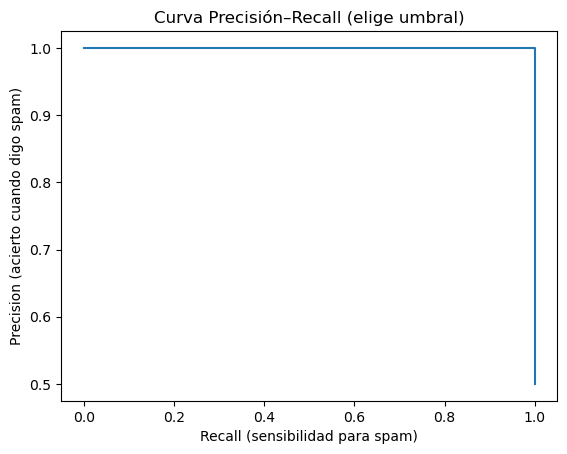

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, average_precision_score
import pandas as pd
import matplotlib.pyplot as plt

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
acc = accuracy_score(y_test, pred)
print(f"\nAccuracy test (umbral 0.5): {acc:.3f}\n")
print("Reporte por clase:\n", classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=[0,1])
print("\nMatriz de confusión:\n", pd.DataFrame(cm, index=["real_legit(0)","real_spam(1)"], columns=["pred_legit(0)","pred_spam(1)"]))

probs = pipe.predict_proba(X_test)[:, 1]
ap = average_precision_score(y_test, probs)
precision, recall, thresholds = precision_recall_curve(y_test, probs)
print(f"\nAverage Precision (área precisión-recall): {ap:.3f}")

umbral = 0.7
pred_u = (probs >= umbral).astype(int)
print(f"\nAccuracy con umbral {umbral}: {accuracy_score(y_test, pred_u):.3f}")
print("Reporte con umbral ajustado:\n", classification_report(y_test, pred_u, digits=3))

plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall (sensibilidad para spam)")
plt.ylabel("Precision (acierto cuando digo spam)")
plt.title("Curva Precisión–Recall (elige umbral)")
plt.show()

In [7]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, df["texto_clean"], df["etiqueta"], cv=5, scoring="f1_macro")
print(f"\nCV 5-fold F1_macro: media={scores.mean():.3f} ±{scores.std():.3f}")


CV 5-fold F1_macro: media=1.000 ±0.000


/home/lord/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/home/lord/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/home/lord/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/home/lord/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 4.
  warnings.warn(
/home/lord/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 's

In [8]:
import joblib

def clasificar_mensajes(textos, threshold=0.7):
    tx = [limpiar(t) for t in textos]
    prob = pipe.predict_proba(tx)[:, 1]
    yhat = (prob >= threshold).astype(int)
    etiqueta = ["spam/estafa" if i==1 else "legítimo" for i in yhat]
    return list(zip(textos, prob.round(3), etiqueta))

nuevos = [
    "Has sido seleccionado para un premio, comparte tus datos aquí",
    "Necesito recuperar acceso a mi cuenta, me pueden ayudar?",
    "Gana dinero rápido hoy, sin riesgo, solo ingresa tu tarjeta",
    "Hola, ¿cuál es el precio del plan anual y si aceptan tarjeta?"
]
print("\nMensajes nuevos (umbral 0.7):")
for t, p, e in clasificar_mensajes(nuevos, threshold=0.7):
    print(f"- '{t}' -> prob_spam={p} | clase={e}")

joblib.dump(pipe, "pipeline_spam.joblib")
print("\nPipeline guardado en pipeline_spam.joblib")

loaded = joblib.load("pipeline_spam.joblib")
print("Test carga:", loaded.predict(["Gana dinero fácil completando este formulario"])[0])


Mensajes nuevos (umbral 0.7):
- 'Has sido seleccionado para un premio, comparte tus datos aquí' -> prob_spam=0.911 | clase=spam/estafa
- 'Necesito recuperar acceso a mi cuenta, me pueden ayudar?' -> prob_spam=0.232 | clase=legítimo
- 'Gana dinero rápido hoy, sin riesgo, solo ingresa tu tarjeta' -> prob_spam=0.893 | clase=spam/estafa
- 'Hola, ¿cuál es el precio del plan anual y si aceptan tarjeta?' -> prob_spam=0.19 | clase=legítimo

Pipeline guardado en pipeline_spam.joblib
Test carga: 1
